# Práctica 1

**Hugo, Fernando, Mario**

## 1. Comprensión de los datos y de los sensores

#### Clasificamos cada uno de los cuatro sensores ambientales como activo o pasivo, indicando la magnitud física que mide cada uno. 

Inicializamos librerías y mostramos el df

In [9]:
import pandas as pd 
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.covariance import EllipticEnvelope
import matplotlib.pyplot as plt

df = pd.read_csv("agri_sensors.csv")
df


,parcela_id,fecha,mes,region,tipo_cultivo,tamano_parcela,humedad_suelo,temperatura_C,temperatura_F,humedad_relativa,luminosidad,ph_suelo,riego_recomendado
0,P040,2025-06-09,2025-06,Este,vid,mediana,28.16,25.92,78.54,48.19,23168.1,6.5,medio
1,P029,2025-06-26,2025-06,Centro,maiz,grande,68.52,16.76,62.17,58.84,17529.5,6.5,bajo
2,P004,2025-06-12,2025-06,Centro,olivo,mediana,70.00,26.79,80.30,48.08,21869.0,6.5,bajo
3,P015,2025-06-20,2025-06,Centro,trigo,mediana,59.72,14.95,58.82,68.29,17132.4,6.5,bajo
4,P002,2025-06-29,2025-06,Sur,trigo,pequeña,NaN,20.69,69.23,54.08,19730.3,6.5,bajo
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,P035,2025-06-25,2025-06,Norte,olivo,pequeña,70.00,15.95,60.75,56.07,15811.8,6.5,bajo
1196,P037,2025-06-16,2025-06,Oeste,vid,pequeña,37.80,21.49,70.71,53.09,18897.7,6.5,medio
1197,P038,2025-06-21,2025-06,Sur,maiz,pequeña,22.53,16.54,61.79,61.57,18802.2,6.5,medio
1198,P029,2025-06-21,2025-06,Centro,maiz,grande,67.50,18.14,64.63,58.77,16750.3,6.5,bajo


Visualizamos información general del df.

In [3]:
df.describe()

,humedad_suelo,temperatura_C,temperatura_F,humedad_relativa,luminosidad,ph_suelo
count,1182.000000,1188.000000,1188.000000,1164.000000,1128.000000,1200.000000
mean,46.509687,22.017584,71.561818,55.054613,19986.012589,6.499417
std,18.854861,4.505871,8.132194,6.287580,3220.486209,0.008644
min,-14.030000,12.710000,54.910000,36.630000,11955.600000,6.400000
25%,33.145000,18.065000,64.440000,50.477500,17215.950000,6.500000
50%,46.390000,21.975000,71.250000,54.965000,19961.300000,6.500000
75%,62.580000,25.982500,78.700000,59.505000,22647.875000,6.500000
max,129.000000,32.010000,89.680000,71.590000,29408.600000,6.600000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   parcela_id         1200 non-null   str    
 1   fecha              1200 non-null   str    
 2   mes                1200 non-null   str    
 3   region             1200 non-null   str    
 4   tipo_cultivo       1200 non-null   str    
 5   tamano_parcela     1200 non-null   str    
 6   humedad_suelo      1182 non-null   float64
 7   temperatura_C      1188 non-null   float64
 8   temperatura_F      1188 non-null   float64
 9   humedad_relativa   1164 non-null   float64
 10  luminosidad        1128 non-null   float64
 11  ph_suelo           1200 non-null   float64
 12  riego_recomendado  1200 non-null   str    
dtypes: float64(6), str(7)
memory usage: 170.3 KB


In [6]:
pd.isnull(df).sum()

parcela_id            0
fecha                 0
mes                   0
region                0
tipo_cultivo          0
tamano_parcela        0
humedad_suelo        18
temperatura_C        12
temperatura_F        12
humedad_relativa     36
luminosidad          72
ph_suelo              0
riego_recomendado     0
dtype: int64

Con este analisis inicial vemos que hay variables con celdas nulas por lo que ahora debemos pensar que podemos hacer con ellas. Hay dos posibilidades o imputar valores o eliminar directamente las celdas. Para ello veremos las características de las columnas y con ello decidiremos. 

In [10]:

# Porcentaje de valores faltantes por columna
print((df.isna().mean() * 100).round(2))




parcela_id           0.0
fecha                0.0
mes                  0.0
region               0.0
tipo_cultivo         0.0
tamano_parcela       0.0
humedad_suelo        1.5
temperatura_C        1.0
temperatura_F        1.0
humedad_relativa     3.0
luminosidad          6.0
ph_suelo             0.0
riego_recomendado    0.0
dtype: float64


Podemos ver que las temperaturas estan relacionadas por la relacion de Celsius y Fahrenheit por lo que antes de imputar valores comprobaremos si en la misma fila aparece el valor de al menos una variable y asi poder sacar el otro sin necesidad de elimina o imputar el valor.

In [12]:
 #Guardamos las medias originales antes de imputar
media_C = df['temperatura_C'].mean()
media_F = df['temperatura_F'].mean()

# Si falta Celsius y tenemos Fahrenheit, convertimos F -> C
mask_C = df['temperatura_C'].isna() & df['temperatura_F'].notna()

df.loc[mask_C, 'temperatura_C'] = (
    df.loc[mask_C, 'temperatura_F'] - 32
) * 5 / 9

# Si falta Fahrenheit y tenemos Celsius, convertimos C -> F
mask_F = df['temperatura_F'].isna() & df['temperatura_C'].notna()

df.loc[mask_F, 'temperatura_F'] = (
    df.loc[mask_F, 'temperatura_C'] * 9 / 5
) + 32

# Si todavía quedan valores faltantes, usamos la media original
df['temperatura_C'] = df['temperatura_C'].fillna(media_C)
df['temperatura_F'] = df['temperatura_F'].fillna(media_F)

pd.isnull(df).sum()


parcela_id            0
fecha                 0
mes                   0
region                0
tipo_cultivo          0
tamano_parcela        0
humedad_suelo        18
temperatura_C         0
temperatura_F         0
humedad_relativa     36
luminosidad          72
ph_suelo              0
riego_recomendado     0
dtype: int64

In [20]:
# Diferencia respecto a la conversión esperada
diferencia = (
    df['temperatura_F']
    - (df['temperatura_C'] * 9/5 + 32)
).abs()

print(diferencia.describe())
print("Filas con diferencia superior a 1:",
      (diferencia > 1).sum())

count    1200.000000
mean        0.075757
std         0.061485
min         0.000000
25%         0.028000
50%         0.060000
75%         0.110500
max         0.340000
dtype: float64
Filas con diferencia superior a 1: 0


De esta manera comprobamos que las columnas son coherentes entre ellas ya que vemos que no hay una diferencia superior a 1F.

Para el resto de valores faltantes elegimos imputar la mediana ya que es un vaor central que no se va a ver muy afectado por los valores extremos o atípicos que pueden mostrar algunas columnas por alguna medición incorrecta.

In [14]:
columnas_mediana = [
    'humedad_suelo',
    'humedad_relativa',
    'luminosidad'
]

for col in columnas_mediana:
    df[col] = df[col].fillna(df[col].median())
    
pd.isnull(df).sum()



parcela_id           0
fecha                0
mes                  0
region               0
tipo_cultivo         0
tamano_parcela       0
humedad_suelo        0
temperatura_C        0
temperatura_F        0
humedad_relativa     0
luminosidad          0
ph_suelo             0
riego_recomendado    0
dtype: int64

Ahora combrobaremos los tipos y categorías mas afondo. Además comprobaremos los valores extremos o sospechosos.

In [15]:
# Tipos de datos
print(df.dtypes)

# Valores diferentes de las variables categóricas
for col in ['region', 'tipo_cultivo',
            'tamano_parcela', 'riego_recomendado']:
    print(f"\n{col}:")
    print(df[col].value_counts())

parcela_id               str
fecha                    str
mes                      str
region                   str
tipo_cultivo             str
tamano_parcela           str
humedad_suelo        float64
temperatura_C        float64
temperatura_F        float64
humedad_relativa     float64
luminosidad          float64
ph_suelo             float64
riego_recomendado        str
dtype: object

region:
region
Este      330
Sur       270
Centro    240
Norte     240
Oeste     120
Name: count, dtype: int64

tipo_cultivo:
tipo_cultivo
maiz     420
olivo    300
vid      270
trigo    210
Name: count, dtype: int64

tamano_parcela:
tamano_parcela
pequeña    510
mediana    450
grande     240
Name: count, dtype: int64

riego_recomendado:
riego_recomendado
bajo     746
medio    355
alto      99
Name: count, dtype: int64


In [17]:
#Pasamos la columna fecha a un tipo de date real para poder trabajar con ello en algun futuro.
df['fecha'] = pd.to_datetime(df['fecha'])

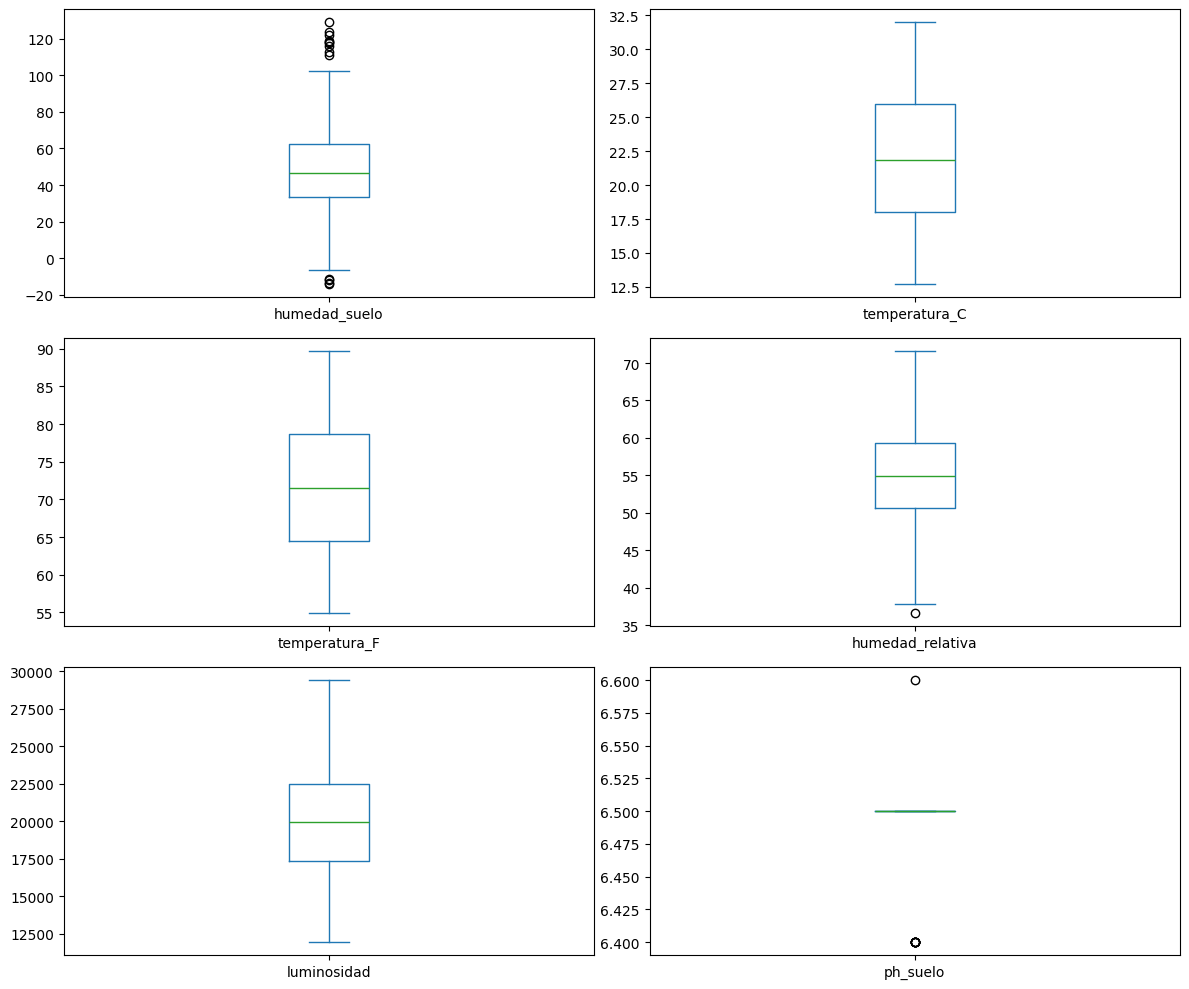

In [26]:

columnas_numericas = [
    'humedad_suelo',
    'temperatura_C',
    'temperatura_F',
    'humedad_relativa',
    'luminosidad',
    'ph_suelo'
]

df[columnas_numericas].plot(
    kind='box',
    subplots=True,
    layout=(3, 2),
    figsize=(12, 10),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.show()


Vemos que humedad_suelo contiene varios valores atípicos por lo que estudiaremos su caso:

In [29]:
Q1 = df['humedad_suelo'].quantile(0.25)
Q3 = df['humedad_suelo'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[
    (df['humedad_suelo'] < limite_inferior) |
    (df['humedad_suelo'] > limite_superior)
]

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)
print("Número de valores atípicos:", len(outliers))

Límite inferior: -10.162499999999994
Límite superior: 105.97749999999999
Número de valores atípicos: 13


In [31]:
#Visualizamos exactamente las filas con esos valores atipicos.
print(
    outliers[
        ['humedad_suelo', 'parcela_id', 'fecha',
         'region', 'tipo_cultivo']
    ].sort_values('humedad_suelo')
)

      humedad_suelo parcela_id      fecha  region tipo_cultivo
374          -14.03       P019 2025-06-22    Este          vid
822          -13.67       P023 2025-06-05    Este         maiz
530          -11.69       P039 2025-06-17   Oeste         maiz
634          -11.07       P025 2025-06-13    Este         maiz
963          110.95       P015 2025-06-02  Centro        trigo
323          112.90       P020 2025-06-30   Norte          vid
398          115.83       P023 2025-06-19    Este         maiz
95           117.61       P023 2025-06-11    Este         maiz
324          118.37       P038 2025-06-10     Sur         maiz
310          118.89       P008 2025-06-02     Sur        trigo
1029         121.83       P021 2025-06-09     Sur         maiz
924          123.32       P013 2025-06-15    Este        olivo
1155         129.00       P026 2025-06-27  Centro         maiz


Al relaizar el estudio y no tener mas contexto sobre como se realizan las mediaciones no podemos determinar si son errores de medicion o si en realidad son correctas las mediciones. En este caso, cabe documentar el hallazgo y ponerse en contrcto con las fincas para saber como manejar estos datos o si las medidas son porcentajes, en cuyo caso habria que eliminar los valores inferiores a 0 y superiores a 100.

Para ir finaliznado con el preprocesado miraremos a ver si hay alguna fila duplicada.

In [21]:
# Filas completamente duplicadas
print("Filas duplicadas:", df.duplicated().sum())

# Combinaciones repetidas de parcela y fecha
print(
    "Combinaciones parcela-fecha duplicadas:",
    df.duplicated(subset=['parcela_id', 'fecha']).sum()
)

Filas duplicadas: 0
Combinaciones parcela-fecha duplicadas: 0


Como no hay filas duplicadas para finalizar nuestro preprocesamiento empezaremos a estudiar la correlación entre las distintas variables numericas

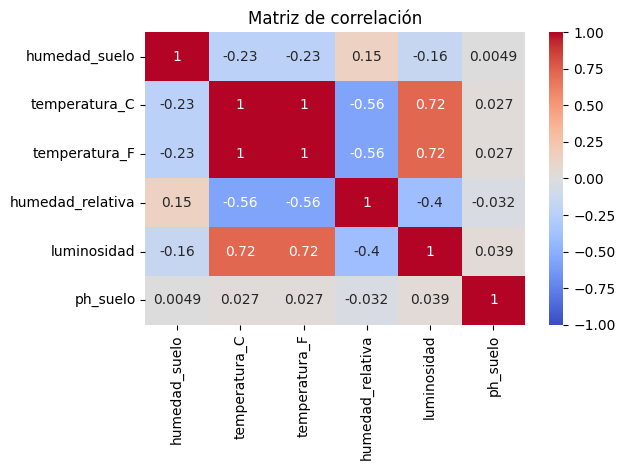

In [28]:

import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos únicamente las columnas numéricas
columnas_numericas = df.select_dtypes(include='number')

# Calculamos la matriz de correlación
correlacion = columnas_numericas.corr()

# Representamos la matriz
sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()
